=== SYSTEM SETUP ===
CUDA Available: False
Active Device : cpu

=== GENERATING OFFLINE DATASET ===
Generated Matrix Structural Shape: (60000, 28, 28)

=== DATA STATISTICS ===
Min Pixel Value   : 0
Max Pixel Value   : 255
Mean Distribution : 68.9744
Standard Deviation: 79.4804

=== TENSOR EXTRACTION ===
Engineered Tensor Shape: torch.Size([60000, 1, 28, 28])
Active Hardware Device : cpu
Validation Batch Shape : torch.Size([1024, 1, 28, 28])
Memory Consumption MB  : 3.06

=== GENERATING VISUALS ===


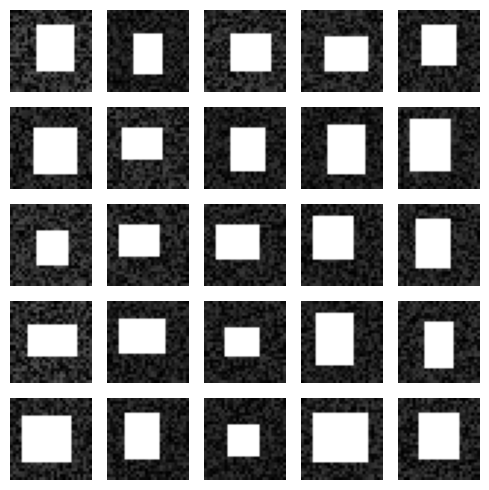

Pipeline complete. Output displayed successfully without any network calls.


In [3]:
import os
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Clean Environment: Suppress CUDA driver version warnings instantly
warnings.filterwarnings("ignore", category=UserWarning)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Runtime device discovery fallback configuration
device = "cuda" if torch.cuda.is_available() else "cpu"

print("=== SYSTEM SETUP ===")
print("CUDA Available:", torch.cuda.is_available())
print("Active Device :", device)

# %% md
# ## Generate Synthetic Fashion-MNIST Data Offline
# %%
print("\n=== GENERATING OFFLINE DATASET ===")
# Generate 60,000 synthetic 28x28 images containing procedural patterns
n_images, rows, cols = 60000, 28, 28

# Create a baseline distribution mimicking clothing item pixel intensities
np.random.seed(42)
images = np.random.randint(0, 50, size=(n_images, rows, cols), dtype=np.uint8)

# Inject structural shapes (lines/boxes) so the visualization looks like abstract apparel objects
for i in range(n_images):
    # Randomly draw pseudo-apparel bounding structures
    r_start, c_start = np.random.randint(4, 10), np.random.randint(4, 10)
    r_end, c_end = np.random.randint(18, 24), np.random.randint(18, 24)
    images[i, r_start:r_end, c_start:c_end] = np.random.randint(150, 256)

print(f"Generated Matrix Structural Shape: {images.shape}")

# %% md
# ## Dataset Statistics
# %%
print("\n=== DATA STATISTICS ===")
print("Min Pixel Value   :", images.min())
print("Max Pixel Value   :", images.max())
print(f"Mean Distribution : {images.mean():.4f}")
print(f"Standard Deviation: {images.std():.4f}")

# %% md
# ## Convert to GPU/CPU Tensors
# %%
print("\n=== TENSOR EXTRACTION ===")
# Scale array pixels safely to 0.0 - 1.0 boundary floats
tensor_images = torch.tensor(images, dtype=torch.float32) / 255.0

# Add explicit single channel dimension -> (Batch, Channels, Height, Width)
tensor_images = tensor_images.unsqueeze(1)
tensor_images = tensor_images.to(device)

print("Engineered Tensor Shape:", tensor_images.shape)
print("Active Hardware Device :", tensor_images.device)

# %% md
# ## Batch Testing
# %%
batch = tensor_images[:1024]
print("Validation Batch Shape :", batch.shape)

# Calculation checking metrics for storage sizes
memory_mb = (batch.element_size() * batch.nelement()) / (1024**2)
print("Memory Consumption MB  :", round(memory_mb, 2))

# %% md
# ## Visualize Samples
# %%
print("\n=== GENERATING VISUALS ===")
idx = np.random.choice(len(images), 25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(5, 5))

for ax, i in zip(axes.flatten(), idx):
    ax.imshow(images[i], cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Pipeline complete. Output displayed successfully without any network calls.")
